In [60]:
pip install ucimlrepo

I tried with data that were not normalized but the result were awful
Data Normalization
The data get normalize towards the mean and the standard deviation, that are here calculate with built in function, in the next block code some of the data are printed to see the results

In [61]:
#Import of all the data from the dataset.
from ucimlrepo import fetch_ucirepo
import numpy as np
import random
import pandas as pd

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y_og = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)

# Standardization of the data to have a uniform learning
for column in X.columns:
  mean = X[column].mean()
  std = X[column].std()
  if std != 0:
    X[column] = (X[column] - mean) / std
  else:
    X[column] = 0

#print(X.describe().round(3))


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

/tmp/ipython-input-266/1959727435.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = (X[column] - mean) / std


In [62]:
# View the first few rows of features
print(X.head())

# View the first few rows of targets
print(y_og.head())

# Or see both together
print(X.head(10))  # Shows first 10 rows
print(y_og.head(10))

# To see the shape (number of rows and columns)
print(X.shape)
print(y_og.shape)

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0       0.142462          2.188664    -2.192664       -0.744721   0.569914   
1       0.451001          3.281982    -2.192664       -0.597594   1.197883   
2       0.451001          2.553104    -1.917405       -0.660648   1.026618   
3       3.073580         -0.362411     1.660957       -0.744721   0.541370   
4       0.142462          2.188664    -2.192664       -0.744721   0.569914   

   free_sulfur_dioxide  total_sulfur_dioxide   density        pH  sulphates  \
0            -1.100055             -1.446247  1.034913  1.812950   0.193082   
1            -0.311296             -0.862402  0.701432 -0.115064   0.999502   
2            -0.874695             -1.092402  0.768128  0.258100   0.797897   
3            -0.762016             -0.986248  1.101609 -0.363840   0.327485   
4            -1.100055             -1.446247  1.034913  1.812950   0.193082   

    alcohol  
0 -0.915394  
1 -0.580023  
2 -0.580023  


In [63]:
print(f"dataset: {len(X)} row")

print(y_og.value_counts())

dataset: 6497 row
quality
6          2836
5          2138
7          1079
4           216
8           193
3            30
9             5
Name: count, dtype: int64


In [64]:
def convert_data(Y):
  Y_copy = Y.copy()
  Y_copy[Y_copy < 6] = -1
  Y_copy[Y_copy >= 6] = 1
  return Y_copy

In [65]:
y = convert_data(y_og)

DATA SPLIT
Data are divided in train and test set respectively, then the output y, which represent the quality of wine, get converted in a binary format that can use to perform binary classification.

In [66]:
#Split data in training and test set, to get only train and ratio put eval_ratio = 0
def split_data(X, y, train_ratio, eval_ratio, test_ratio):
  #randomize my data
  indices = np.random.permutation(len(X))
  if hasattr(X, 'iloc'):
    X_shuffle = X.iloc[indices]
    y_shuffle = y.iloc[indices]
  else:
    X_shuffle = X[indices]
    y_shuffle = y[indices]

  #get length of every part
  train_part = int(len(X) * train_ratio)
  eval_part = int(train_part + len(X) * eval_ratio)
  #split dataset in different parts.
  X_train = X_shuffle[:train_part]
  y_train = y_shuffle[:train_part]
  X_eval = X_shuffle[train_part:eval_part]
  y_eval = y_shuffle[train_part:eval_part]
  X_test = X_shuffle[eval_part:]
  y_test = y_shuffle[eval_part:]
  return X_train, y_train, X_eval, y_eval, X_test, y_test


Model define both the SVM and the LR, when defining the class you can choose which class by using a string "SVM" if i want to use the SVM model, "LR" otherwise.

In [67]:
class Model:
  #First thing to do is initialize at random the weight matrix. The number of column is given by the len of X that we want to multiply
  def __init__(self, X, Y, model, X_val = None, Y_val = None):
    self.X = X
    self.Y = Y
    self.model = model
    self.w = np.random.rand(len(X.columns))
    self.b = 0
    self.loss = []
    self.acc = []
    self.epochs = []
    self.val_loss = []
    self.val_acc = []
    self.val_epochs = []


  def training(self, learning_rate, epochs, lam, X_val = None, Y_val = None):
    self.Y = self.Y.values
    #for n epoch i have to multiply w and x and calculate the error (distance from y)
    self.X = self.X.values

    if self.model == "SVM":
      for epoch in range(epochs):
        epoch_loss = 0
        epoch_acc = 0
        for i in range(len(self.X)):
          loss, acc = self.training_step_svm(i, learning_rate, lam)
          epoch_loss += loss
          epoch_acc += acc

        self.loss.append(epoch_loss/len(self.X))
        self.epochs.append(epoch)
        self.acc.append(epoch_acc/len(self.X))
        if X_val is not None and Y_val is not None:
            epoch_val_loss, epoch_val_acc = self.evaluate(X_val, Y_val)
            self.val_loss.append(epoch_val_loss)
            self.val_acc.append(epoch_val_acc)
            self.val_epochs.append(epoch)

        if epoch % 10 == 0:
          print("Epoch:", epoch)

    else:
      for epoch in range(epochs):
        epoch_loss = 0
        epoch_acc = 0
        for i in range(len(self.X)):
          loss, acc = self.training_step_lr(i, learning_rate, lam)
          epoch_loss += loss
          epoch_acc += acc

        self.loss.append(epoch_loss/len(self.X))
        self.epochs.append(epoch)
        #calculate accuracy
        self.acc.append(epoch_acc/len(self.X))
        if X_val is not None and Y_val is not None:
            epoch_val_loss, epoch_val_acc = self.evaluate(X_val, Y_val)
            self.val_loss.append(epoch_val_loss)
            self.val_acc.append(epoch_val_acc)
            self.val_epochs.append(epoch)

        if epoch % 10 == 0:
          print("Epoch:", epoch)


  def training_step_svm(self, i, learning_rate, lam):
    #get the values to calculation
    x = self.X[i]
    y = self.Y[i]

    #execute the multiplication
    condition = y * (np.dot(self.w, x) + self.b)
    loss = max(0, 1 - condition)
    regularization = lam * np.dot(self.w, self.w)
    total_loss = loss + regularization

    if condition > 0:
      acc = 1
    else:
      acc = 0

    #Hinge loss, if condition is right still push the values.
    if condition >= 1:
      #correct classification (concordance between y and w*x), i just use the regularization to keep w small
      self.w = self.w - learning_rate * (2 * lam * self.w)
    else:
      #update to shift the hyperplane
      self.w = self.w - learning_rate * (2 * lam * self.w - y*x)
      self.b = self.b + learning_rate * y

    #this are added to plot the loss and accuracies
    return total_loss, acc

  def training_step_lr(self, i, learning_rate, lam):
      x_i = self.X[i]
      y_i = self.Y[i]
      #Calculation of the probability of an event given his inputs
      z = np.dot(self.w, x_i) + self.b

      #Loss here is for plotting purpose after
      loss = np.log2(1 + np.exp(-y_i * z))
      regularization = (lam / 2) * np.dot(self.w, self.w) #last one is norm of w
      total_loss = loss + regularization

      if y_i * z > 0:
        acc = 1
      else:
        acc = 0

      #adjust weight and bias accordingly to gradient of loss
      prob = 1 / (1 + np.exp(-y_i * z))
      error = 1 - prob
      update = - (y_i * x_i) * error + lam * self.w
      self.w = self.w - learning_rate * update
      self.b = self.b + learning_rate * y_i * error
      return total_loss, acc


  #With new data we want to predict on a test set X
  def predict(self, X):
    predictions = []
    if self.model == "SVM":
      for i in range(len(X)):
          x = X.iloc[i].values
          prediction = np.sign(np.dot(self.w, x) + self.b)
          predictions.append(prediction)
    else:
      for i in range(len(X)):
        #probability
        z = np.dot(self.w, X.iloc[i].values) + self.b
        prediction = 1 / (1 + np.exp(-z))
        #convert the probability in a real output.
        if prediction >= 0.5:
          prediction = 1
        else:
          prediction = -1

        predictions.append(prediction)

    return np.array(predictions).ravel()


  def accuracy(self, X, Y):
    correct = 0
    total = 0
    if self.model == "SVM":
      for i in range(len(X)):
        prediction = np.sign(np.dot(self.w,X[i]) + self.b)
        if prediction == Y[i]:
          correct += 1
          total += 1
        else:
          total += 1
    else:
      for i in range(len(X)):
        z = np.dot(self.w,X[i]) + self.b
        #convert the prob into a prediction
        if z >= 0:
          prediction = 1
        else:
          prediction = -1
        #check the prediction
        if prediction == Y[i]:
          correct += 1
          total += 1
        else:
          total += 1

    #this is the correction rate through all the X
    return correct / total

  def evaluate(self, X_val, Y_val):
    X_val = X_val.values
    Y_val = Y_val.values
    val_loss = 0
    val_acc = 0

    for i in range(len(X_val)):
      x = X_val[i]
      y = Y_val[i]
      z = np.dot(self.w, x) + self.b

      if self.model == "SVM":
        val_loss += max(0, 1 - y * z)
        if y * z > 0:
          val_acc += 1
      else:
        exp_term = np.exp(np.clip(-y * z, -500, 500))
        val_loss += np.log2(1 + exp_term)
        if y * z > 0:
          val_acc += 1

    return val_loss/len(X_val), val_acc/len(X_val)


Performance metric

In [68]:
def accuracy(pred, Y):
    predictions = pred
    accuracy_score = np.mean(predictions == Y)
    return accuracy_score

def precision(pred, Y):
    predictions = pred
    true_positives = np.sum((predictions == 1) & (Y == 1))
    false_positives = np.sum((predictions == 1) & (Y == -1))
    precision_score = true_positives / (true_positives + false_positives)
    return precision_score

def recall(pred, Y):
    predictions = pred
    true_positives = np.sum((predictions == 1) & (Y == 1))
    false_negatives = np.sum((predictions == -1) & (Y == 1))
    recall_score = true_positives / (true_positives + false_negatives)
    return recall_score

def F1_score(pred, Y):
    prec = precision(pred, Y)
    rec = recall(pred, Y)
    f1_score = 2 * (prec * rec) / (prec + rec)
    return f1_score

def performance_metric(pred, Y):
  print("Accuracy:", accuracy(pred, Y))
  print("Precision:", precision(pred, Y))
  print("Recall:", recall(pred, Y))
  print("F1 score:", F1_score(pred, Y))
  return accuracy(pred, Y), precision(pred, Y), recall(pred, Y), F1_score(pred, Y)

Evaluation of the two models: using self made hyperparameter(not fine tuned, no cross-validation). A problem that occurred was that the recall in logistic regression was 1 due to a bad choice of the lambda parameter.

In [80]:
split_ratio = 0.7
eval_ratio = 0.15
test_ratio = 0.15
X_train, y_train, X_eval, y_eval, X_test, y_test = split_data(X, y, split_ratio, eval_ratio ,test_ratio)

model_svm = Model(X_train, y_train, "SVM", X_val = X_eval ,Y_val = y_eval)
model_lr = Model(X_train, y_train, "LR", X_val = X_eval ,Y_val = y_eval)

#Note that the best hyperparameter find with cross validation indicate to use both learning rate and lambda as 0.001. if wanted someone can run the svm
#code commented (but remember to comment the other training)

#model_svm.training(0.001, 50, 0.001, X_val = X_eval ,Y_val = y_eval)
model_svm.training(0.01, 50, 0.01, X_val = X_eval ,Y_val = y_eval)
model_lr.training(0.001, 50, 0.001, X_val = X_eval ,Y_val = y_eval)

pred_svm = model_svm.predict(X_test)
pred_lr = model_lr.predict(X_test)

y_test_flat = np.array(y_test).ravel()

print("SVM test:")
performance_metric(pred_svm, y_test_flat)
print("\n")
print("Logistic regression test:")
performance_metric(pred_lr, y_test_flat)

Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
SVM test:
Accuracy: 0.7284836065573771
Precision: 0.764792899408284
Recall: 0.8298555377207063
F1 score: 0.7959969207082372


Logistic regression test:
Accuracy: 0.735655737704918
Precision: 0.7711738484398217
Recall: 0.8330658105939005
F1 score: 0.800925925925926


(np.float64(0.735655737704918),
 np.float64(0.7711738484398217),
 np.float64(0.8330658105939005),
 np.float64(0.800925925925926))

Loss and Accuracy of the models

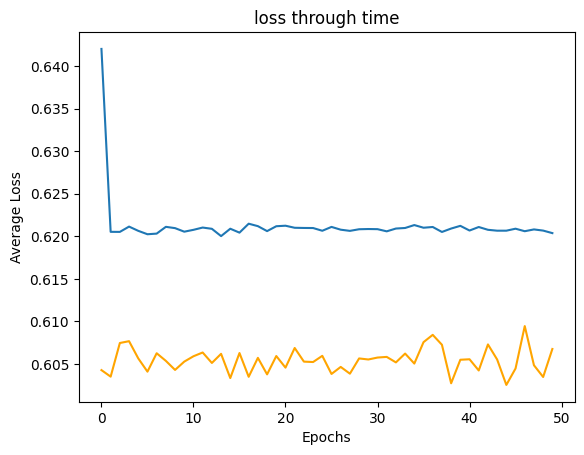

In [81]:
import matplotlib.pyplot as plt

plt.plot(model_svm.epochs, model_svm.loss, label = "Training Loss")

plt.plot(model_svm.val_epochs, model_svm.val_loss, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('loss through time')
plt.show()

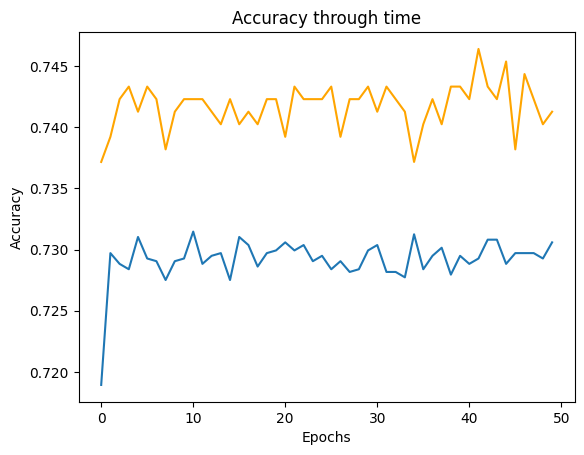

In [82]:
plt.plot(model_svm.epochs, model_svm.acc, label = "Training Accuracy")

plt.plot(model_svm.val_epochs, model_svm.val_acc, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy through time')
plt.show()

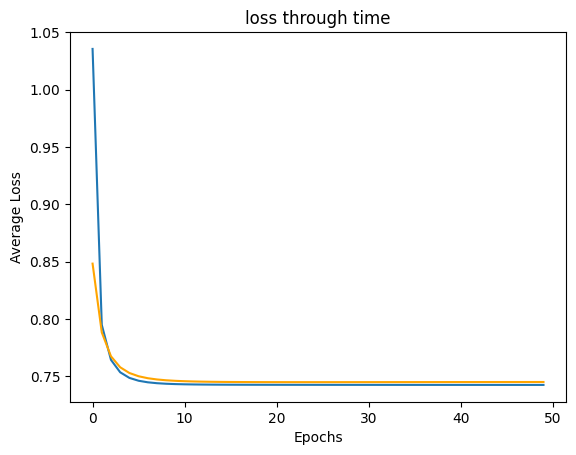

In [83]:
import matplotlib.pyplot as plt

plt.plot(model_lr.epochs, model_lr.loss, label = "Training Loss")

plt.plot(model_lr.val_epochs, model_lr.val_loss, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('loss through time')
plt.show()

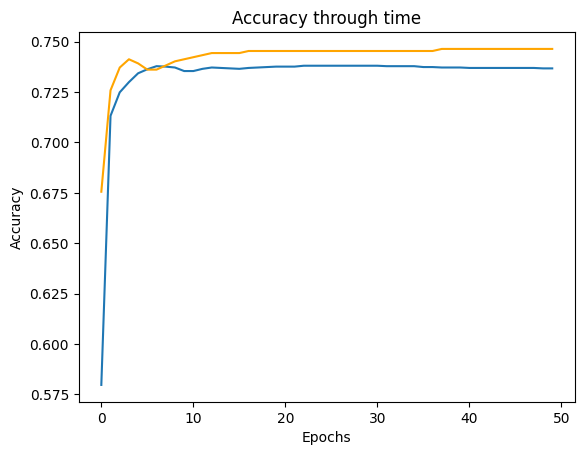

In [84]:
plt.plot(model_lr.epochs, model_lr.acc, label = "Training Accuracy")

plt.plot(model_lr.val_epochs, model_lr.val_acc, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy through time')
plt.show()

Cross Validation. The cross validation is implemented to try different model with a certain learning rate, epochs, lambda, and potentially even the kernelized function. A grid search is then used to try all the possible combination of learning rates, epochs and lambda to get the best results in a pool. Optionally also the kernelized version can be tested by adding the kernel.

In [70]:
#kernel params are the params that are needed to run the alghoritm
def cross_fold_validation(X, Y, k, model, learning_rate, epochs, lam):
  indices = np.random.permutation(len(X))
  X_shuffle = X.iloc[indices]
  Y_shuffle = Y.iloc[indices]

  #split train in k different folds
  X_folds = np.array_split(X_shuffle, k)
  Y_folds = np.array_split(Y_shuffle, k)

  folds_scores = []
  models = []

  #training
  for i in range(k):
    X_eval = X_folds[i]
    Y_eval = Y_folds[i]

    X_train_fold = pd.concat([x for j, x in enumerate(X_folds) if j != i]).reset_index(drop=True)
    Y_train_fold = pd.concat([y for j, y in enumerate(Y_folds) if j != i]).reset_index(drop=True)

    if model == "SVM":
      clf = Model(X_train_fold, Y_train_fold, "SVM")
      clf.training(learning_rate, epochs, lam)
      pred = clf.predict(X_eval)
    else:
      clf = Model(X_train_fold, Y_train_fold, "LR")
      clf.training(learning_rate, epochs, lam)
      pred = clf.predict(X_eval)

    acc, prec, rec, f1 = performance_metric(pred, Y_eval.values.ravel())
    folds_scores.append(acc)
    models.append(clf)

    print(f"Fold {i+1}: {acc}")

  avg_score = np.mean(folds_scores, axis=0)
  print("Average score is:", avg_score ,"for lam = ", lam, "and learning rate =", learning_rate, "with number of epochs:", epochs)
  return avg_score



def grid_search(X, Y, k, model, learning_rate_range, epochs_range, lam_range):
  best_score = 0
  best_lam = 0
  best_lr = 0
  best_epoch = 0
  for lam in lam_range:
    for lr in learning_rate_range:
      for epochs in epochs_range:
        #This time we had to classify wines, accuracy is the best parameter to check
        accuracy = cross_fold_validation(X, Y, k, model, lr, epochs, lam)
        if accuracy > best_score:
          best_score = accuracy
          best_lam = lam
          best_lr = lr
          best_epoch = epochs


  print("Best score is: ", best_score, "with lam = ", best_lam, "with lr = ", best_lr, "with epochs = ", best_epoch)
  return best_score, best_lam, best_lr, best_epoch




Because a cross fold need many minutes the SVM and the LR are done in separate blocks.

In [71]:
learning_rates = [0.01, 0.005, 0.001]
#epochs  can be tested also over 100 but it become much more expensive
epochs_range = [50, 100]
lam_range = [0.001, 0.01, 0.1]
model_svm = "SVM"
k = 5

X_cross = pd.concat([X_train, X_eval]).reset_index(drop=True)
Y_cross = pd.concat([y_train, y_eval]).reset_index(drop=True)

score, lam, lr, epoch = grid_search(X_cross, Y_cross, k, model_svm, learning_rates, epochs_range, lam_range)

final_model_svm = Model(X_train, y_train, model_svm)
final_model_svm.training(lr, epoch, lam, X_val = X_eval, Y_val = y_eval)

print("valutazione sul testo")
pred = final_model_svm.predict(X_test)
final_acc, final_prec, final_rec, final_f1 = performance_metric(pred, y_test.values.ravel())
print("best learning rate: " ,lr, "best epoch: " ,epoch, "best lam: ", lam)



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7402714932126697
Precision: 0.7566539923954373
Recall: 0.8627167630057804
F1 score: 0.8062120189061446
Fold 1: 0.7402714932126697
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7436594202898551
Precision: 0.7591888466413181
Recall: 0.865606936416185
F1 score: 0.8089128966914247
Fold 2: 0.7436594202898551
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7246376811594203
Precision: 0.7443324937027708
Recall: 0.8540462427745664
F1 score: 0.7954239569313593
Fold 3: 0.7246376811594203
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7327898550724637
Precision: 0.7653846153846153
Recall: 0.842031029619182
F1 score: 0.8018804566823372
Fold 4: 0.7327898550724637
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7545289855072463
Precision: 0.7715355805243446
Recall: 0.8753541076487252
F1 score: 0.8201725282017251
Fold 5: 0.7545289855072463
Average score is: 0.739177487048331 for lam =  

In [72]:
learning_rates = [0.01, 0.005, 0.001]
epochs_range = [50, 100]
lam_range = [0.001, 0.01, 0.1]
model_lr = "LR"
k = 5

#the data were splitted before in the block above this

score, lam, lr, epoch = grid_search(X_cross, Y_cross, k, model_lr, learning_rates, epochs_range, lam_range)

final_model_lr = Model(X_train, y_train, model_lr)
final_model_lr.training(lr, epoch, lam, X_val = X_eval, Y_val = y_eval)
pred = final_model_lr.predict(X_test)
final_acc, final_prec, final_rec, final_f1 = performance_metric(pred, y_test.values.ravel())
print("best learning rate: " ,lr, "best epoch: " ,epoch, "best lam: ", lam)

Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7321266968325791
Precision: 0.7724867724867724
Recall: 0.8248587570621468
F1 score: 0.7978142076502732
Fold 1: 0.7321266968325791
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7463768115942029
Precision: 0.7855297157622739
Recall: 0.8421052631578947
F1 score: 0.8128342245989306
Fold 2: 0.7463768115942029
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7590579710144928
Precision: 0.7850467289719626
Recall: 0.8484848484848485
F1 score: 0.8155339805825242
Fold 3: 0.7590579710144928
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7382246376811594
Precision: 0.7688172043010753
Recall: 0.8301886792452831
F1 score: 0.7983251919050942
Fold 4: 0.7382246376811594
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Accuracy: 0.7228260869565217
Precision: 0.7457180500658761
Recall: 0.833578792341679
F1 score: 0.7872044506258693
Fold 5: 0.7228260869565217
Average score is: 0.7397224408157911 for lam =

Kernel Function
-polynomial function
-Gaussian function

In [22]:
def kernel_polynomial_function(x, x_1, c = 1, d = 2):
  #the kernel function have to map the features in high dimensional space and make the dot product
  return (c + np.dot(x, x_1)) ** d

def kernel_gaussian_function(X, Y, sigma):
  diff = X - Y
  sqr_dist = np.dot(diff, diff)
  K = np.exp(-sigma * sqr_dist)
  return K

Extend the svm and the lr model in a kernelized form

In [23]:
class kernel_model(Model):
  def __init__(self, X, Y, kernel_function, kernel_params, model):
    self.X = X
    self.Y = Y
    self.kernel_params = kernel_params
    self.alpha = np.zeros(len(X))
    self.kernel_function = kernel_function
    self.b = 0
    self.K = None
    self.epochs = []
    self.loss = []
    self.acc = []
    self.val_loss = []
    self.val_acc = []
    self.val_epochs = []
    self.model = model

  def training(self, learning_rate, epochs, lam, X_val = None, Y_val = None):
    if hasattr(self.X, 'values'):
      self.X = self.X.values

    self.Y = np.array(self.Y).ravel()

    # 1. Precompute the Kernel Matrix, which tell us the similarity in the new space between all the points
    n_samples = len(self.X)
    print(f"Precomputing Kernel Matrix ({n_samples}x{n_samples})... this might take a minute.")
    self.K = np.zeros((n_samples, n_samples))

    for i in range(n_samples):
        for j in range(i, n_samples):
            k_val = self.kernel_function(self.X[i], self.X[j], **self.kernel_params)
            self.K[i, j] = k_val
            self.K[j, i] = k_val

    print("Kernel Matrix computed. Starting training...")

    initial_lr = learning_rate
    if self.model == "SVM":
      for epoch in range(epochs):
        epoch_loss = 0
        epoch_acc = 0
        #here i add a learning rate that change with time
        learning_rate = initial_lr / (1 + epoch*0.05)
        for i in range(len(self.X)):
          loss_step, correct = self.training_step_svm(i, learning_rate, lam)
          epoch_loss += loss_step
          epoch_acc += correct

        self.loss.append(epoch_loss/len(self.X))
        self.epochs.append(epoch)
        self.acc.append(epoch_acc/len(self.X))


        if epoch % 10 == 0: # Print every 10 epochs
          #self.acc.append(self.accuracy(self.X, self.Y))
          print("Epoch:", epoch)
          if X_val is not None and Y_val is not None:
            epoch_val_loss, epoch_val_acc = self.evaluate(X_val, Y_val)
            self.val_loss.append(epoch_val_loss)
            self.val_acc.append(epoch_val_acc)
            self.val_epochs.append(epoch)
    else:
      for epoch in range(epochs):
        epoch_loss = 0
        epoch_acc = 0
        #here i try adding a learning rate that change with time
        learning_rate = initial_lr / (1 + epoch*0.05)
        for i in range(len(self.X)):
          loss_step, correct = self.training_step_lr(i, learning_rate, lam)
          epoch_loss += loss_step
          epoch_acc += correct

        self.loss.append(epoch_loss/len(self.X))
        self.epochs.append(epoch)
        self.acc.append(epoch_acc/len(self.X))


        if epoch % 10 == 0: # Print every 10 epochs
          #self.acc.append(self.accuracy(self.X, self.Y))
          print("Epoch:", epoch)
          if X_val is not None and Y_val is not None:
            epoch_val_loss, epoch_val_acc = self.evaluate(X_val, Y_val)
            self.val_loss.append(epoch_val_loss)
            self.val_acc.append(epoch_val_acc)
            self.val_epochs.append(epoch)

  def training_step_svm(self, i, learning_rate, lam):
    y = self.Y[i]

    # 2. Vectorized calculation of 'z' using the precomputed Kernel Matrix
    # z = sum(alpha_j * y_j * K_ij) + b
    z = np.dot(self.alpha * self.Y, self.K[i]) + self.b

    condition = y * z

    #by the hinge loss we know
    loss = max(0, 1 - condition)
    regularization = lam/2 * (self.alpha[i] * self.alpha[i])
    total_loss = loss + regularization

    if condition > 0:
      correct = 1
    else:
      correct = 0

    #condition correct, update just using the regularization term, else also use the derivative of hinge loss
    #alpha shrink to keep the alphas low
    self.alpha = self.alpha - learning_rate * (lam * self.alpha)
    #i double "punish" the alpha[i] only if it classify incorrectly, else i just shrink parameters
    if condition < 1:
      self.alpha[i] = self.alpha[i] + learning_rate
      self.b = self.b + learning_rate * y

    return loss, correct

  def training_step_lr(self, i, learning_rate, lam):
    y = self.Y[i]

    z = np.dot(self.alpha * self.Y, self.K[i]) + self.b
    exp_term = np.exp(np.clip(-y * z, -500, 500))

    loss = np.log2(1 + exp_term)
    regularization = (lam / 2)*np.dot(self.alpha[i],self.alpha[i])
    tot_loss = loss + regularization
    #calculate prob that estimate is correct
    sigma = 1 / (1 + exp_term)
    if z*y > 0:
      correct = 1
    else:
      correct = 0

    #gradient loss and alpha update
    #gradient = (-1/np.log2(1 + np.exp(-y * z))) * (-y * np.exp(-y * z)) + lam * self.alpha[i]
    self.alpha = self.alpha - learning_rate * (lam * self.alpha)
    error = 1 - sigma
    self.alpha[i] = self.alpha[i] + learning_rate * error
    self.b = self.b + learning_rate * y * error

    return loss, correct

  def predict(self, X_test):
      predictions = []
      X_train = self.X # stored from training

      if hasattr(X_test, 'values'):
        X_test = X_test.values

      # For prediction on new data, we have to compute the kernel against all training points
      for i in range(len(X_test)):
        x = X_test[i]
        z = self.b

        if self.model == "SVM":
          # z = sum(alpha_j * y_j * K(x_train_j, x_new))
          for j in range(len(X_train)):
            # Only compute for non-zero alphas (Support Vectors) to save time
            if self.alpha[j] != 0:
                #compute the similarity between the two points
                k = self.kernel_function(X_train[j], x, **self.kernel_params)
                z += self.alpha[j] * self.Y[j] * k

          #z positive mean +1, else -1
          predictions.append(np.sign(z))
        else:
          for j in range(len(X_train)):
            # Only compute for non-zero alphas (Support Vectors) to save time
            #if abs(self.alpha[j]) > 0.001:
              k = self.kernel_function(X_train[j], x, **self.kernel_params)
              z += self.alpha[j] * self.Y[j] * k
          #Note that this is equivalent to do the sigmoid function, for z >= 0 it is: 1/(1+e^z) >= 0.5
          if z >= 0:
            prediction = 1
          else:
            prediction = -1
          predictions.append(prediction)

      return np.array(predictions).ravel()

  def evaluate(self, X_val, Y_val):
    if hasattr(X_val, 'values'):
      X_val = X_val.values

    Y_val = np.array(Y_val).ravel()

    val_loss = 0
    val_acc = 0
    for i in range(len(X_val)):
      x = X_val[i]
      y = Y_val[i]
      z = self.b
      for j in range(len(self.X)):
        if self.alpha[j] != 0:
          k = self.kernel_function(self.X[j], x, **self.kernel_params)
          z += self.alpha[j] * self.Y[j] * k

      if self.model == "SVM":
        val_loss += max(0, 1 - y * z)
        #if concordant, then classification is correct
        if y * z > 0:
          val_acc += 1
      else:
        exp_term = np.exp(np.clip(-y * z, -500, 500))
        val_loss += np.log2(1 + exp_term)
        if y * z > 0:
          val_acc += 1

    return val_loss/len(X_val), val_acc/len(X_val)

Training of the various kind of models. While the initialization is done in the same block, the training is executed in different blocks, because it requires time to train just once

In [25]:
#Running the models
split_ratio = 0.7
eval_ratio = 0.15
test_ratio = 0.15
X_train, y_train, X_eval, y_eval, X_test, y_test = split_data(X, y, split_ratio,eval_ratio, test_ratio)
param_poly = {'c': 1, 'd': 2}
param_gaus = {'sigma': 0.1}
model_poly = kernel_model(X_train, y_train, kernel_polynomial_function, param_poly, "SVM")
model_gaus = kernel_model(X_train, y_train, kernel_gaussian_function, param_gaus, "SVM")
model_lr_poly = kernel_model(X_train, y_train, kernel_polynomial_function, param_poly, "LR")
model_lr_gaus = kernel_model(X_train, y_train, kernel_gaussian_function, param_gaus, "LR")


Each training was done on different block to speed up.

In [26]:
model_poly.training(learning_rate=0.001, epochs=101, lam=0.001, X_val = X_eval, Y_val = y_eval)

Precomputing Kernel Matrix (4547x4547)... this might take a minute.
Kernel Matrix computed. Starting training...
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100


In [27]:
model_gaus.training(learning_rate=0.001, epochs=101, lam=0.001, X_val = X_eval, Y_val = y_eval)

Precomputing Kernel Matrix (4547x4547)... this might take a minute.
Kernel Matrix computed. Starting training...
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100


In [28]:
model_lr_poly.training(learning_rate=0.001, epochs=101, lam=0.001, X_val = X_eval, Y_val = y_eval)

Precomputing Kernel Matrix (4547x4547)... this might take a minute.
Kernel Matrix computed. Starting training...
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100


In [29]:
model_lr_gaus.training(learning_rate=0.001, epochs=101, lam=0.001, X_val = X_eval, Y_val = y_eval)

Precomputing Kernel Matrix (4547x4547)... this might take a minute.
Kernel Matrix computed. Starting training...
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100


Plottting the graph. The loss and the accuracy are here showed both during training and test.

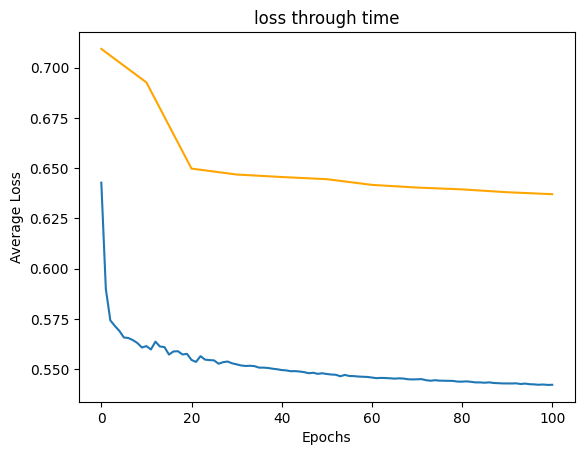

In [30]:
import matplotlib.pyplot as plt

plt.plot(model_poly.epochs, model_poly.loss, label = "Training Loss")

plt.plot(model_poly.val_epochs, model_poly.val_loss, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('loss through time')
plt.show()


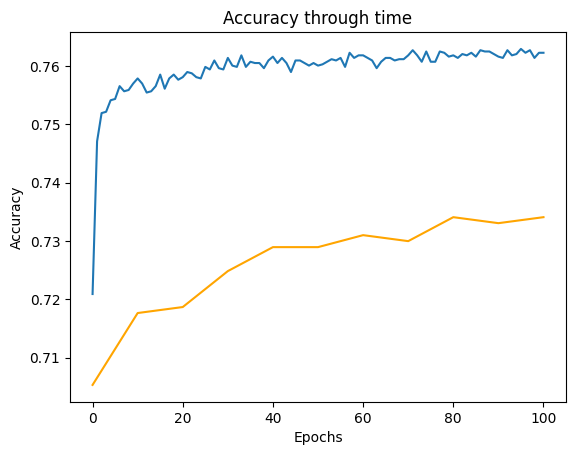

In [31]:
import matplotlib.pyplot as plt

plt.plot(model_poly.epochs, model_poly.acc, label = "Training Acc")

plt.plot(model_poly.val_epochs, model_poly.val_acc, label="Validation Acc", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy through time')
plt.show()

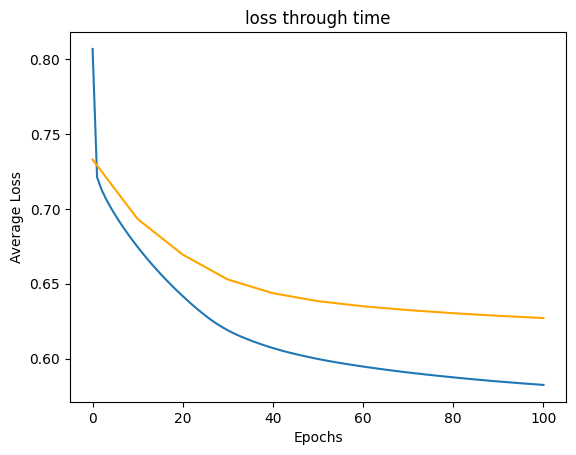

In [32]:
import matplotlib.pyplot as plt

plt.plot(model_gaus.epochs, model_gaus.loss, label = "Training Loss")

plt.plot(model_gaus.val_epochs, model_gaus.val_loss, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('loss through time')
plt.show()


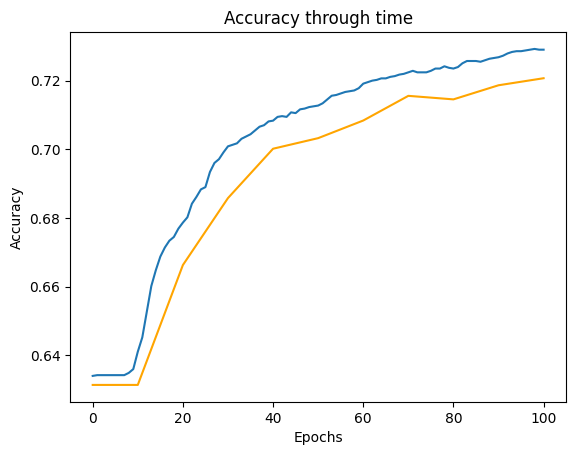

In [33]:
import matplotlib.pyplot as plt

plt.plot(model_gaus.epochs, model_gaus.acc, label = "Training accuracy")

plt.plot(model_gaus.val_epochs, model_gaus.val_acc, label="Validation accuracy", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy through time')
plt.show()

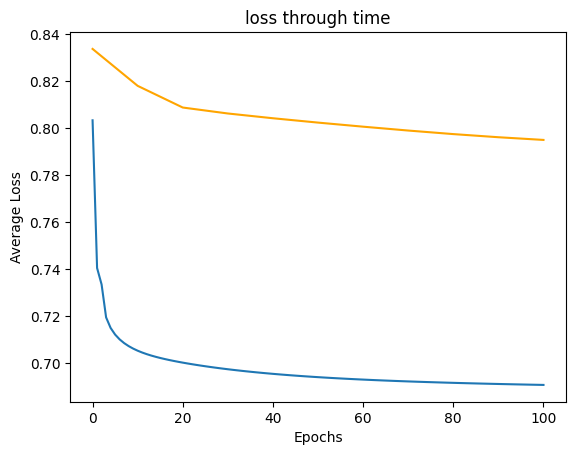

In [34]:
import matplotlib.pyplot as plt

plt.plot(model_lr_poly.epochs, model_lr_poly.loss, label = "Training Loss")

plt.plot(model_lr_poly.val_epochs, model_lr_poly.val_loss, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('loss through time')
plt.show()

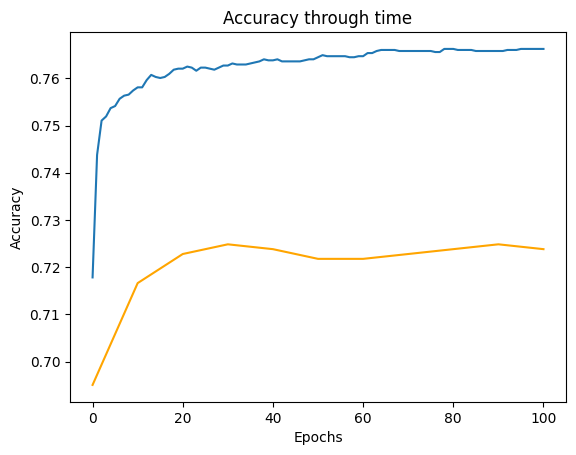

In [35]:
plt.plot(model_lr_poly.epochs, model_lr_poly.acc, label = "Training Accuracy")

plt.plot(model_lr_poly.val_epochs, model_lr_poly.val_acc, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy through time')
plt.show()

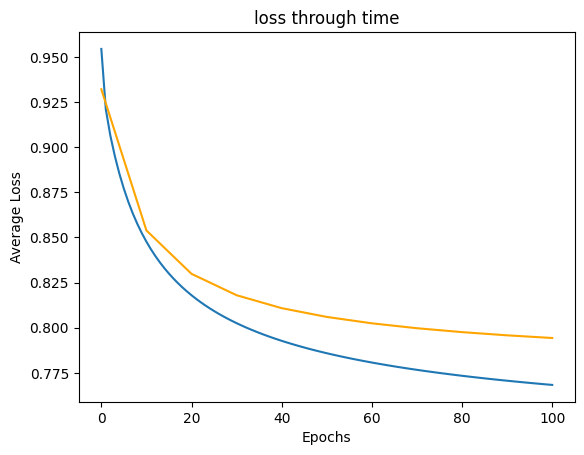

In [36]:
import matplotlib.pyplot as plt

plt.plot(model_lr_gaus.epochs, model_lr_gaus.loss, label = "Training Loss")

plt.plot(model_lr_gaus.val_epochs, model_lr_gaus.val_loss, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.title('loss through time')
plt.show()

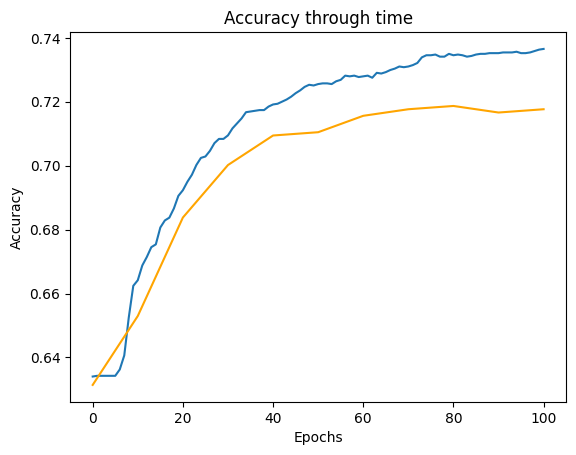

In [37]:
plt.plot(model_lr_gaus.epochs, model_lr_gaus.acc, label = "Training Accuracy")

plt.plot(model_lr_gaus.val_epochs, model_lr_gaus.val_acc, label="Validation Loss", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy through time')
plt.show()

Metric of the various models

In [38]:
predictions = model_poly.predict(X_test)
final_acc, final_prec, final_rec, final_f1 = performance_metric(predictions, y_test.values.ravel())


Accuracy: 0.7622950819672131
Precision: 0.7784256559766763
Recall: 0.8697068403908795
F1 score: 0.8215384615384614


In [39]:
predictions = model_gaus.predict(X_test)
final_acc, final_prec, final_rec, final_f1 = performance_metric(predictions, y_test.values.ravel())

Accuracy: 0.7305327868852459
Precision: 0.7264516129032258
Recall: 0.9169381107491856
F1 score: 0.8106551475881929


In [40]:
predictions = model_lr_poly.predict(X_test)
final_acc, final_prec, final_rec, final_f1 = performance_metric(predictions, y_test.values.ravel())

Accuracy: 0.7704918032786885
Precision: 0.7867647058823529
Recall: 0.8713355048859935
F1 score: 0.8268933539412675


In [41]:
predictions = model_lr_gaus.predict(X_test)
final_acc, final_prec, final_rec, final_f1 = performance_metric(predictions, y_test.values.ravel())

Accuracy: 0.7407786885245902
Precision: 0.7353324641460235
Recall: 0.9185667752442996
F1 score: 0.8167994207096307


Confusion Matrix. Given a prediction and the real results we can confront where the model fail and get some interesting conclusions, like how dataset was build.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix(y, y_pred):
  true_positive = 0
  true_negative = 0
  false_positive = 0
  false_negative = 0
  for yt, yp in zip(y, y_pred):
    if yt == 1 and yp == 1:
      true_positive += 1
    elif yt == 1 and yp == -1:
      false_negative += 1
    elif yt == -1 and yp == 1:
      false_positive += 1
    else:
      true_negative += 1

  conf_matrix = np.array([[true_negative, false_positive], [false_negative, true_positive]])
  fig, ax = plt.subplots(figsize=(6, 5))
  cax = ax.imshow(conf_matrix, cmap='Blues')
  plt.colorbar(cax)

  for i in range(2):
    for j in range(2):
      ax.text(j, i, str(conf_matrix[i, j]), va='center', ha='center', color='black', fontsize=16, fontweight='bold')

  plt.xticks([0, 1], ['Bad wine', 'Good wine'])

  plt.yticks([0, 1], ['Bad wine', 'Good wine'])

  plt.xlabel('Model prediction')

  plt.ylabel('Real data')

  plt.title('Confusion matrix')

  plt.show()

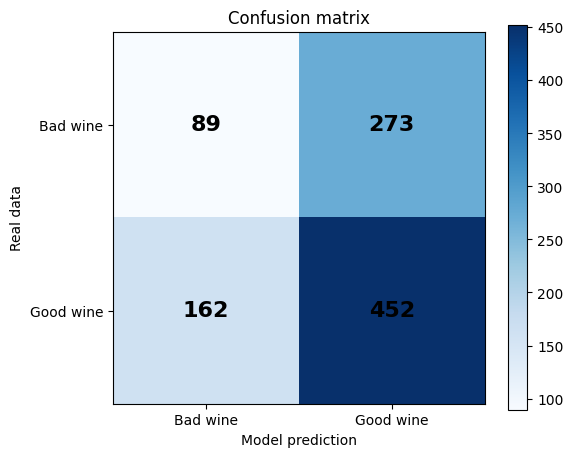

In [43]:
confusion_matrix(y_test.values.ravel(), pred_svm)

OPTIONAL: DATA AUGMENTATION
Data are augmented using Smote. A random point is selected and the euclidean distance is calculated with respect to all the other points, after that a k number of closest points are selected and a neighbor between them is chosen randomly. using the data point and the neighbor a new point is created with feature that are between the point and the neighbor.
The successive block of code is done to augment data of many times.
Data are undersampled by removing points with label 1

In [44]:
#get a random data point and his neighbor (using Euclidean distance)
def get_random_data_point(X):
  rd_num = random.randint(0,len(X) - 1)
  #sample is the value that i use to generate synthetic data
  sample = X.iloc[rd_num].values
  label = y.iloc[rd_num].values
  distances = []
  for i in range(len(X)):
    distances.append(np.sqrt(np.sum(np.square(X.iloc[i].values - sample))))
  return distances, sample, label

#Check the closest neighboors
def get_closest_neighboors(distances,sample, X ,k):
  #Sort the indices of the closest neighboors
  nearest_indices = np.argsort(distances)[1:k+1]
  #Now i produce a synthetic data (SMOTE)
  random_neighboor_index = np.random.choice(nearest_indices)
  neighbor = X.iloc[random_neighboor_index].values
  synthetic_data = sample + (neighbor - sample) * np.random.uniform(0, 1)

  print("The sample was:")
  print(pd.Series(sample, index=X.columns))  # Convert to Series with column names
  print("\nThe label was:")
  print(pd.Series(label, index=y.columns))
  print("\nThe closest neighbor was:")
  print(pd.Series(neighbor, index=X.columns))
  print("\nThe synthetic data is:")
  print(pd.Series(synthetic_data, index=X.columns))
  print("\n" + "Another data" + "\n")

  return synthetic_data





In [45]:
#Here i execute the code above as many times as i want to get n artificial samples
n = 500
artificial_data = []
artificial_labels = []
smp = 0
while smp < n:
  distances, sample , label = get_random_data_point(X)
  #The if is used to create negative sample.
  if label < 6:
    new_data = get_closest_neighboors(distances,sample, X ,5)
    artificial_data.append(new_data)
    artificial_labels.append(label)
    smp += 1

# Here i convert the data to be sure it's dataframe
artificial_df = pd.DataFrame(artificial_data, columns=X.columns)
artificial_y = pd.DataFrame(artificial_labels, columns=y.columns)
#Concatenation of the two dataframe (original and synthetic)
X_augmented = pd.concat([X, artificial_df], ignore_index=True)
y_augmented = pd.concat([y, artificial_y], ignore_index=True)

#Some examples
print(artificial_df.head())
print(artificial_y.head())

Output streaming troncato alle ultime 5000 righe.
The closest neighbor was:
fixed_acidity          -0.937423
volatile_acidity       -0.605370
citric_acid            -0.334668
residual_sugar         -0.744721
chlorides              -0.229319
free_sulfur_dioxide     0.533803
total_sulfur_dioxide    0.959902
density                -0.299010
pH                      2.621472
sulphates               0.058679
alcohol                -0.412338
dtype: float64

The synthetic data is:
fixed_acidity          -1.420958
volatile_acidity       -0.496581
citric_acid            -0.581170
residual_sugar         -0.132995
chlorides              -0.587187
free_sulfur_dioxide     0.937436
total_sulfur_dioxide    0.801462
density                 0.119089
pH                      3.624011
sulphates              -0.121865
alcohol                -0.036921
dtype: float64

Another data

The sample was:
fixed_acidity          -0.011807
volatile_acidity       -1.212769
citric_acid             0.215849
residual_sugar

In [46]:
df = X.copy()

df['quality'] = y

df_good = df[df['quality'] == 1]

df_bad = df[df['quality'] == -1]

n_bad = len(df_bad)

df_good_undersampled = df_good.sample(n=n_bad, random_state=42)

df_undersampled = pd.concat([df_good_undersampled, df_bad])

y_undersampled = df_undersampled['quality']

X_undersampled = df_undersampled.drop('quality', axis=1)
print(f"Undersampling completato! Nuova dimensione X: {len(X_undersampled)}, nuova dimensione y: {len(y_undersampled)}")



Undersampling completato! Nuova dimensione X: 4768, nuova dimensione y: 4768


In [47]:
X_array = np.array(X_undersampled)

Y_array = np.array(y_undersampled)

index = np.arange(len(X_array))

np.random.shuffle(index)

X_array = X_array[index]

Y_array = Y_array[index]